In [1]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.offline import init_notebook_mode
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff
import plotly.io as pio
from plotly.offline import init_notebook_mode
import warnings

warnings.filterwarnings("ignore")
pio.renderers.default = "iframe"

2026-04-28 08:01:48.703048: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777363308.899621      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777363308.955049      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777363309.384563      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777363309.384608      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777363309.384611      23 computation_placer.cc:177] computation placer alr

# 1. Veri Setlerini İndirme ve İnceleme

In [2]:
dataset_path = '/kaggle/input/datasets/msambare/fer2013'
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

In [3]:
# Veri Yapısını İnceleme
def count_images_in_dir(directory):
    counts = {}
    if os.path.exists(directory):
        for emotion in os.listdir(directory):
            emotion_path = os.path.join(directory, emotion)
            if os.path.isdir(emotion_path):
                counts[emotion] = len(os.listdir(emotion_path))
    else:
        print(f"Klasör bulunamadı: {directory}")
    return counts


train_counts = count_images_in_dir(train_dir)
test_counts = count_images_in_dir(test_dir)

In [4]:
if train_counts and test_counts:
    df_counts = pd.DataFrame({'Eğitim (Train)': train_counts, 'Test': test_counts})
    df_counts.loc['Toplam'] = df_counts.sum()
    
    print("FER2013 Veri Seti Yapısı (Görsel Sayıları):")
    print("-" * 50)
    print(df_counts)

FER2013 Veri Seti Yapısı (Görsel Sayıları):
--------------------------------------------------
          Eğitim (Train)  Test
surprise            3171   831
fear                4097  1024
angry               3995   958
neutral             4965  1233
sad                 4830  1247
disgust              436   111
happy               7215  1774
Toplam             28709  7178


In [5]:
init_notebook_mode(connected=True)
pio.renderers.default = 'kaggle' 

fig = px.bar(
    x=list(train_counts.keys()), 
    y=list(train_counts.values()), 
    color=list(train_counts.keys()),
    labels={'x': 'Duygu Sınıfı', 'y': 'Eğitim Setindeki Görsel Sayısı'},
    title='FER2013 Eğitim Seti Duygu Dağılımı'
)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show(renderer='iframe')

# 2. Veri Ön İşleme

In [6]:
IMG_SIZE = 48
BATCH_SIZE = 64

# Piksel Değerlerini Normalize Etme
datagen = ImageDataGenerator(rescale=1./255)

In [7]:
# Görselleri Boyutlandırma ve Sete Ayırma (Eğitim)
print("Eğitim (Train) verileri hazırlanıyor...")
train_generator = datagen.flow_from_directory(
    train_dir,                        
    target_size=(IMG_SIZE, IMG_SIZE), 
    color_mode="grayscale",           
    batch_size=BATCH_SIZE,            
    class_mode='categorical',         
    shuffle=True           
)

Eğitim (Train) verileri hazırlanıyor...
Found 28709 images belonging to 7 classes.


In [8]:
# Görselleri Boyutlandırma ve Sete Ayırma (Test)
print("\nTest verileri hazırlanıyor...")
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False                     
)


Test verileri hazırlanıyor...
Found 7178 images belonging to 7 classes.


In [9]:
images, labels = next(train_generator)

In [10]:
class_indices = train_generator.class_indices
class_names = dict((v, k) for k, v in class_indices.items())

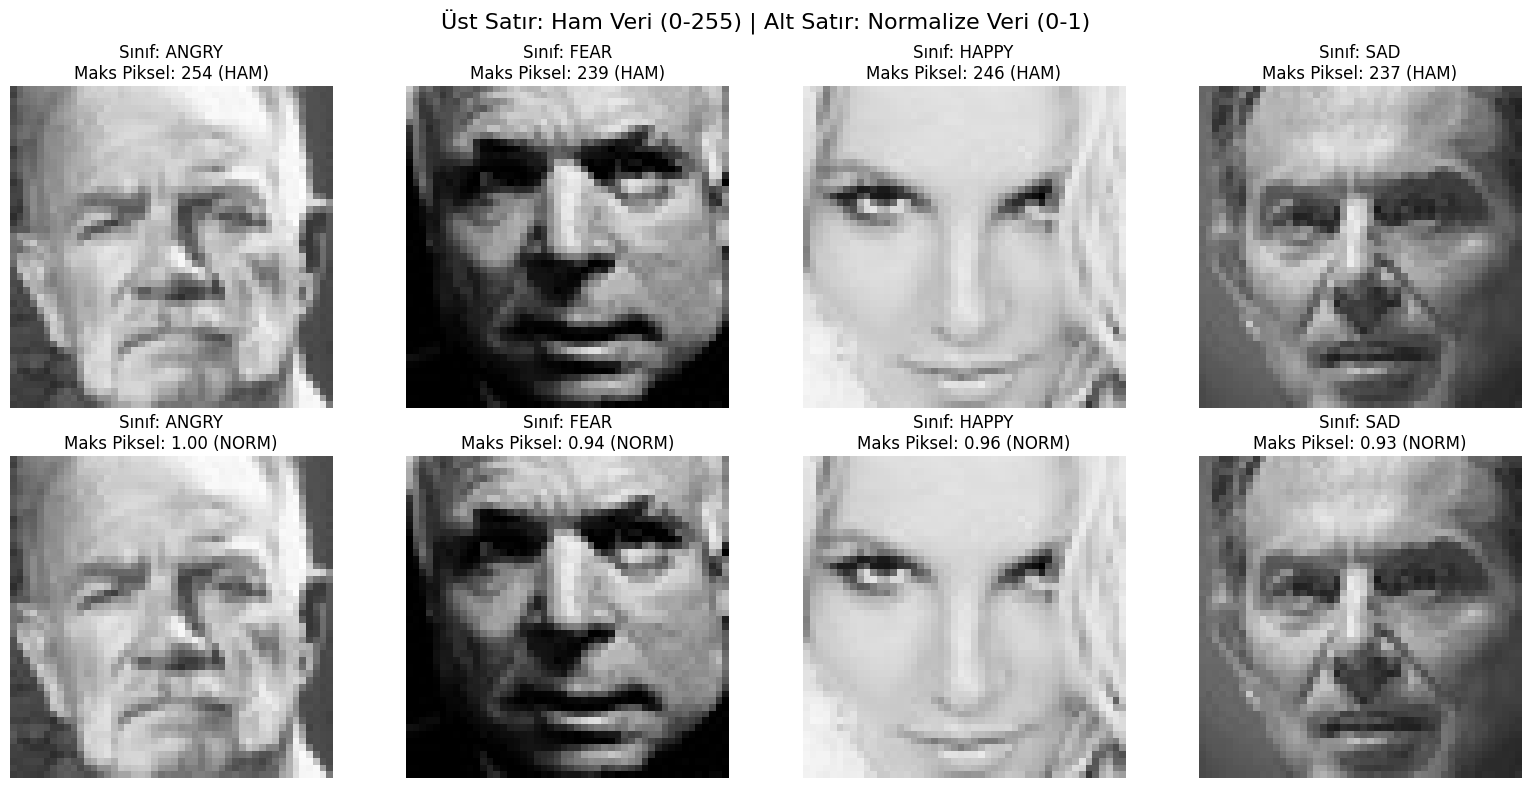

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Üst Satır: Ham Veri (0-255) | Alt Satır: Normalize Veri (0-1)", fontsize=16)

for i in range(4):
    img_normalized = images[i].squeeze() 
    img_raw = (img_normalized * 255).astype(np.uint8) 

    label_idx = np.argmax(labels[i]) 
    emotion_name = class_names[label_idx]
    
    # Ham Veri Çizimi
    axes[0, i].imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f"Sınıf: {emotion_name.upper()}\nMaks Piksel: {img_raw.max()} (HAM)")
    axes[0, i].axis('off')

    # Normalize Veri Çizimi
    axes[1, i].imshow(img_normalized, cmap='gray', vmin=0.0, vmax=1.0)
    axes[1, i].set_title(f"Sınıf: {emotion_name.upper()}\nMaks Piksel: {img_normalized.max():.2f} (NORM)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 3. Görsel Duygu Tanıma Modeli Oluşturma

In [12]:
model = Sequential()

# 1. Evrişim (Convolution) Bloğu
model.add(Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

I0000 00:00:1777363355.014178      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
# 2. Evrişim Bloğu
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

In [14]:
# 3. Evrişim Bloğu
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

In [15]:
model.add(Dropout(0.25))

# Tam Bağlantılı (Fully Connected) Katmanlar
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.50)) # Burada dropout oranını artırıyoruz
model.add(Dense(7, activation='softmax')) # 7 farklı duygu sınıfı için çıkış katmanı

In [16]:
# --- 2. MODELİN DERLENMESİ VE EĞİTİM AYARLARI ---
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Eğitimi kontrol altında tutmak için Callbacks:
# EarlyStopping: Eğer 7 epoch boyunca test başarısı artmazsa eğitimi durdur.
# ModelCheckpoint: En yüksek test başarısına ulaşılan modeli kaydet.
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
checkpoint = ModelCheckpoint('cnn_emotion_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

In [17]:
# --- 3. MODELİN EĞİTİLMESİ ---
print("Model eğitimi başlıyor. Lütfen arkanıza yaslanın ve GPU'nun işini yapmasını bekleyin...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=50, # Maksimum 50 tur dönecek ama EarlyStopping genelde daha erken keser
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[early_stop, checkpoint]
)
print("Eğitim Tamamlandı!")

Model eğitimi başlıyor. Lütfen arkanıza yaslanın ve GPU'nun işini yapmasını bekleyin...
Epoch 1/50


I0000 00:00:1777363362.031001      83 service.cc:152] XLA service 0x7c410c008670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777363362.031055      83 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777363362.932589      83 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/448 ━━━━━━━━━━━━━━━━━━━━ 1:39:28 13s/step - accuracy: 0.1094 - loss: 3.5371

I0000 00:00:1777363370.744327      83 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.2613 - loss: 2.2932

...

448/448 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.4688 - loss: 1.3196 - val_accuracy: 0.5897 - val_loss: 1.0949
Epoch 11/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.6209 - loss: 1.0109 - val_accuracy: 0.5724 - val_loss: 1.1507
Epoch 12/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6250 - loss: 1.0675 - val_accuracy: 0.5622 - val_loss: 1.1713
Epoch 13/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 50s 110ms/step - accuracy: 0.6455 - loss: 0.9540 - val_accuracy: 0.5865 - val_loss: 1.1159
Epoch 14/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.6562 - loss: 0.9939 - val_accuracy: 0.5876 - val_loss: 1.1124
Epoch 15/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6649 - loss: 0.9101

448/448 ━━━━━━━━━━━━━━━━━━━━ 46s 101ms/step - accuracy: 0.6649 - loss: 0.9101 - val_accuracy: 0.5904 - val_loss: 1.1526
Epoch 16/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6875 - loss: 0.9628 - val_accuracy: 0.5904 - val_loss: 1.1504
Epoch 17/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6915 - loss: 0.8374

448/448 ━━━━━━━━━━━━━━━━━━━━ 62s 138ms/step - accuracy: 0.6914 - loss: 0.8374 - val_accuracy: 0.6123 - val_loss: 1.0690
Epoch 18/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7188 - loss: 0.8223

448/448 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.7188 - loss: 0.8223 - val_accuracy: 0.6133 - val_loss: 1.0676
Epoch 19/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.7115 - loss: 0.7835

448/448 ━━━━━━━━━━━━━━━━━━━━ 59s 132ms/step - accuracy: 0.7115 - loss: 0.7836 - val_accuracy: 0.6212 - val_loss: 1.1012
Epoch 20/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7500 - loss: 0.7477 - val_accuracy: 0.6203 - val_loss: 1.1076
Epoch 21/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 58s 130ms/step - accuracy: 0.7499 - loss: 0.6907 - val_accuracy: 0.6197 - val_loss: 1.0968
Epoch 22/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7500 - loss: 0.6365 - val_accuracy: 0.6190 - val_loss: 1.1001
Epoch 23/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.7765 - loss: 0.6160 - val_accuracy: 0.6140 - val_loss: 1.1302
Epoch 24/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7969 - loss: 0.6285 - val_accuracy: 0.6147 - val_loss: 1.1267
Epoch 25/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 43s 95ms/step - accuracy: 0.7948 - loss: 0.5618 - val_accuracy: 0.6197 - val_loss: 1.1697
Epoch 26/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7969 - loss: 0.6307 - val_a

# 4. Sonuçları Görselleştirme

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = list(range(1, len(acc) + 1))

In [19]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Eğitim ve Test Doğruluğu (Accuracy)', 'Eğitim ve Test Kaybı (Loss)'))

# Doğruluk (Accuracy) Grafikleri
fig.add_trace(go.Scatter(x=epochs_range, y=acc, mode='lines+markers', name='Eğitim Doğruluğu', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs_range, y=val_acc, mode='lines+markers', name='Test Doğruluğu', line=dict(color='orange')), row=1, col=1)

# Kayıp (Loss) Grafikleri
fig.add_trace(go.Scatter(x=epochs_range, y=loss, mode='lines+markers', name='Eğitim Kaybı', line=dict(color='blue')), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs_range, y=val_loss, mode='lines+markers', name='Test Kaybı', line=dict(color='orange')), row=1, col=2)

fig.update_layout(title='CNN Modeli Eğitim Performansı', xaxis_title='Epoch (Tur)', template='plotly_white')
fig.show(renderer='iframe')

# Final Test Skorunu Yazdırma
loss, accuracy = model.evaluate(test_generator)
print(f"\nFinal Test Doğruluğu (Accuracy): %{accuracy*100:.2f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.5715 - loss: 1.2261

Final Test Doğruluğu (Accuracy): %62.15


In [20]:
model.save('cnn_emotion_model.h5')
print("CNN Modeli başarıyla kaydedildi!")

CNN Modeli başarıyla kaydedildi!


In [21]:
init_notebook_mode(connected=True)
pio.renderers.default = 'kaggle' 

test_generator.reset()
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
# Gerçek etiketleri alıyoruz
y_true = test_generator.classes

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step


In [22]:
# Sınıf isimlerini jeneratörden çekme (angry, disgust, fear, happy, neutral, sad, surprise)
class_names = list(test_generator.class_indices.keys())

# 3. Karışıklık Matrisini Hesaplama
cm = confusion_matrix(y_true, y_pred)

# 4. Plotly ile İnteraktif Görselleştirme
fig_cm = ff.create_annotated_heatmap(
    z=cm.tolist(),
    x=class_names, # X ekseni Tahminler
    y=class_names, # Y ekseni Gerçekler
    colorscale='Blues',
    showscale=True
)

fig_cm.update_layout(
    title='FER2013 CNN Modeli Karışıklık Matrisi',
    title_x=0.5,
    xaxis_title='Modelin Tahmin Ettiği Duygu',
    yaxis_title='Gerçek Duygu'
)
fig_cm.show(renderer='iframe')